In [1]:
import os
# --- Environment config (v5-style; edit these two paths for your machine) ---
os.environ["AD2_ROOT"]   = "/home/devuser/workspace/code/Anomalib/anomalib/datasets/MVTec_AD_2"
os.environ["SMOKE_TEST"] = "1"          # 1 = pilot (few cats/images, fast); 0 = full run
os.environ["BACKBONE"]   = "dinov3"     # dinov3 (default) | dinov2 | stub
print("AD2_ROOT:", os.environ["AD2_ROOT"], "| SMOKE_TEST:", os.environ["SMOKE_TEST"])

AD2_ROOT: /home/devuser/workspace/code/Anomalib/anomalib/datasets/MVTec_AD_2 | SMOKE_TEST: 1


In [2]:
import os, glob, subprocess
os.makedirs("./weights", exist_ok=True)
# symlink the cached DINOv3 weight (v5 used vitl16) into ./weights/
_cache = "/home/devuser/.cache/torch/hub/checkpoints/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth"
if os.path.exists(_cache):
    _dst = "./weights/" + os.path.basename(_cache)
    if not os.path.exists(_dst):
        try: os.symlink(_cache, _dst)
        except OSError: pass
# discover any DINOv3 weight, prefer smaller variant
_hits = sorted(glob.glob("./weights/dinov3_*_pretrain_*.pth") +
               glob.glob("/home/devuser/.cache/torch/hub/checkpoints/dinov3_*_pretrain_*.pth"),
               key=lambda p: {"vits16":0,"vitb16":1,"vitl16":2,"vith16plus":3}.get(
                   next((k for k in ("vits16","vitb16","vitl16","vith16plus") if k in p), "vitl16"), 2))
DINOV3_WEIGHTS = os.path.abspath(_hits[0]) if _hits else ""
DINOV3_HUB = next((f"dinov3_{k}" for k in ("vits16","vitb16","vitl16","vith16plus") if DINOV3_WEIGHTS and k in DINOV3_WEIGHTS), "dinov3_vitl16")
# clone the DINOv3 code repo (torch.hub local load needs it)
DINOV3_REPO = os.path.abspath("./dinov3_repo")
if DINOV3_WEIGHTS and not os.path.isdir(DINOV3_REPO):
    subprocess.run(["git", "clone", "https://github.com/facebookresearch/dinov3.git", DINOV3_REPO],
                   capture_output=True, text=True)
if not DINOV3_WEIGHTS:
    os.environ["BACKBONE"] = "dinov2"     # graceful fallback if weights absent
print("DINOv3 weights:", DINOV3_WEIGHTS or "(none -> dinov2)", "| variant:", DINOV3_HUB, "| repo:", os.path.isdir(DINOV3_REPO))

DINOv3 weights: /home/devuser/workspace/code/Anomalib/anomalib/gsoc_workspace/weights/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth | variant: dinov3_vitl16 | repo: True


# Subtractive Anomaly Generation on MVTec AD 2 -- v6 (feature-space)

v5 detected real defects well but its synthetic *subtractive* anomalies collapsed on the
subtractive categories (synth AU-PRO 0.21 vs real 0.59): a convincing pixel "missing part" is
nearly invisible in DINOv3 feature space, so the detector trained on it gets no signal. v6 scraps
the pixel-space operators and synthesizes the anomaly directly **in DINOv3 feature space**.

**Method.** DINOv3 patch features -> estimate a **substrate / absence prototype** `b` (bare-material
feature) from low-saliency normals -> subtractive anomaly = push a foreground feature `u` toward
`b`: `a = u + alpha*(b-u) + noise`, truncated to `r1<||a-u||<r2` (GLASS near-in-distribution) ->
train an MLP discriminator on normal(0) vs synthetic(1) features (SimpleNet / GLASS).

**Three arms, same real test set:** `NORMAL_ONLY` (DINOv3 kNN dist-to-bank = floor) | `SYNTH` (ours)
| `REAL_ORACLE` (discriminator on real defect features = ceiling). Success = `SYNTH` reaches
`REAL_ORACLE` and clears `NORMAL_ONLY`, especially on the subtractive family.

References: GLASS 2407.09359 - SimpleNet 2303.15140 - SuperADD 2605.14808 - MVTec AD 2 2503.21622.

## 0.2 Hypotheses

| # | Question | Metric | YES threshold |
|---|---|---|---|
| **H1** | Does synth reach real-oracle parity? | AU-PRO@0.05 | `SYNTH` within 0.05 of `REAL_ORACLE` |
| **H2** | Does synth beat the normal-only floor? | AU-PRO@0.05 | `SYNTH` > `NORMAL_ONLY` per category |
| **H3** | Do subtractive categories recover? | per-family AU-PRO | subtractive gap-to-oracle < 0.10 (v5 was 0.38) |
| **H4** | Are synth features near-in-distribution? | feature-consistency | synth deviation overlaps real-defect band |

## 0.3 Setup

AU-PRO@0.05 (threshold-free) leads; F1@best is the oracle best-threshold F1. Feature extraction is
native-tiled DINOv3 (full run) so tiny defects keep their resolution; resized in smoke for speed.

In [3]:
import glob, math, random, warnings, json, time, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


SMOKE_TEST = bool(int(os.environ.get("SMOKE_TEST", "1")))
SEEDS      = [0] if SMOKE_TEST else [0, 1, 2]
set_seed(0)
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
NATIVE     = not SMOKE_TEST                          # native-tiled features in the full run
WORK_RES   = int(os.environ.get("WORK_RES", "1024"))  # resize path (smoke); patch-multiple
TILE, OVERLAP, EVAL_RES = 640, 128, 256
OUTPUT_DIR = "./out_v6"; os.makedirs(OUTPUT_DIR, exist_ok=True)
CKPT = os.path.join(OUTPUT_DIR, "v6.json")
print("device:", DEVICE, "| smoke:", SMOKE_TEST, "| native:", NATIVE)

device: cuda | smoke: True | native: False


## 0.5 AD 2 discovery and pre-flight

In [4]:
PILOT = ["can", "walnuts", "rice", "wall_plugs", "wallplugs"]
_TAG = {"can": "subtractive", "fabric": "subtractive", "fruitjelly": "contamination", "rice": "contamination",
        "sheetmetal": "subtractive", "vial": "mixed", "wallplugs": "subtractive", "walnuts": "mixed"}
def _norm(c): return c.replace("_", "").replace("-", "").lower()


def _imgs(d):
    out = []
    for e in ("png", "PNG"):
        out += glob.glob(os.path.join(d, f"*.{e}"))
    return sorted(out)


def _find_root():
    for r in [os.environ.get("AD2_ROOT", "").strip(), "mvtec_ad_2_reduced",
              os.path.expanduser("~/Downloads/mvtec_ad_2_reduced")]:
        try:
            if r and os.path.isdir(r) and any(os.path.isdir(os.path.join(r, d, "train", "good")) for d in os.listdir(r)):
                return r
        except OSError:
            pass
    return None


ROOT = _find_root()
assert ROOT, "MVTec AD 2 root not found. Set os.environ['AD2_ROOT'] (folder with <cat>/train/good)."
ALL_CATS = sorted(d for d in os.listdir(ROOT) if os.path.isdir(os.path.join(ROOT, d, "train", "good")))
CATS = ([c for c in PILOT if c in ALL_CATS] if SMOKE_TEST else ALL_CATS) or ALL_CATS
CATS = CATS[:int(os.environ.get("MAX_CATS", str(len(CATS))))]
FAMILY = {c: _TAG.get(_norm(c), "subtractive") for c in ALL_CATS}
print("root:", ROOT, "| using:", CATS)


def get_split(cat):
    base = os.path.join(ROOT, cat, "test_public")
    bad, mask = [], []
    for p in _imgs(os.path.join(base, "bad")):
        mp = os.path.join(base, "ground_truth", "bad", os.path.splitext(os.path.basename(p))[0] + "_mask.png")
        if os.path.isfile(mp):
            bad.append(p); mask.append(mp)
    return dict(normals=_imgs(os.path.join(ROOT, cat, "train", "good")),
                val=_imgs(os.path.join(ROOT, cat, "validation", "good")),
                good=_imgs(os.path.join(base, "good")), bad=bad, mask=mask)


print(pd.DataFrame([dict(cat=c, tag=FAMILY[c], **{k: len(v) for k, v in get_split(c).items()}) for c in CATS]).to_string(index=False))

root: /home/devuser/workspace/code/Anomalib/anomalib/datasets/MVTec_AD_2 | using: ['can', 'walnuts', 'rice', 'wallplugs']
      cat           tag  normals  val  good  bad  mask
      can   subtractive      412   46    72   90    90
  walnuts         mixed      432   48    60   90    90
     rice contamination      313   35    42   90    90
wallplugs   subtractive      293   33    60   90    90


## 1. DINOv3 backbone and feature extraction

Frozen DINOv3 (default), DINOv2 or a deterministic stub (auto-fallback so the notebook never
hard-errors). Multi-layer patch tokens concatenated on a common grid. `NATIVE` tiles the full-res
image (SuperADD-style); otherwise it resizes to `WORK_RES`.

In [5]:
_BB = [None]
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def _backbone():
    if _BB[0] is not None:
        return _BB[0]
    kind = os.environ.get("BACKBONE", "dinov3")
    try:
        if kind == "dinov3":
            m = torch.hub.load(DINOV3_REPO, DINOV3_HUB, source="local", weights=DINOV3_WEIGHTS); patch = 16
        elif kind == "dinov2":
            m = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14"); patch = 14
        else:
            raise RuntimeError("stub")
        m = m.eval().to(DEVICE)
        nb = len(m.blocks); layers = sorted({nb // 4 - 1, nb // 2 - 1, 3 * nb // 4 - 1, nb - 1})
        _BB[0] = ("dino", m, patch, layers)
        print(f"backbone: {kind} ({nb} blocks, patch {patch})")
    except Exception as e:
        print(f"backbone '{kind}' -> stub (plumbing only): {type(e).__name__}: {e}")
        g = torch.Generator().manual_seed(0)
        _BB[0] = ("stub", torch.randn(3 * 16 * 16, 128, generator=g), 16, None)
    return _BB[0]


def _load(path, res=None):
    img = Image.open(path).convert("RGB")
    if res:
        img = img.resize((res, res), Image.BILINEAR)
    return torch.from_numpy(np.asarray(img, np.float32) / 255.0).permute(2, 0, 1)


@torch.no_grad()
def _feats(img_t):
    kind, m, patch, layers = _backbone()
    if kind == "stub":
        C, H, W = img_t.shape; hp, wp = H // patch, W // patch
        pt = img_t[:, :hp * patch, :wp * patch].unfold(1, patch, patch).unfold(2, patch, patch)
        return F.normalize(pt.permute(1, 2, 0, 3, 4).reshape(hp * wp, -1) @ m, dim=1), (hp, wp)
    x = (img_t.unsqueeze(0).to(DEVICE) - _MEAN.to(DEVICE)) / _STD.to(DEVICE)
    outs = m.get_intermediate_layers(x, n=layers, reshape=True)
    hp, wp = outs[0].shape[2], outs[0].shape[3]
    outs = [F.interpolate(o, size=(hp, wp), mode="bilinear", align_corners=False) for o in outs]
    return F.normalize(torch.cat(outs, 1)[0].reshape(-1, hp * wp).T.float().cpu(), dim=1), (hp, wp)


def _tile_starts(L, T_):
    if L <= T_:
        return [0]
    s = list(range(0, L - T_ + 1, max(1, T_ - OVERLAP)))
    return s if s[-1] == L - T_ else s + [L - T_]


@torch.no_grad()
def extract(path):
    _, _, patch, _ = _backbone()
    if not NATIVE:
        return _feats(_load(path, (WORK_RES // patch) * patch))
    img = _load(path); H, W = img.shape[1], img.shape[2]
    Tp = (TILE // patch) * patch; gh, gw = H // patch, W // patch
    acc = cnt = None
    for y in _tile_starts(H, Tp):
        for x in _tile_starts(W, Tp):
            f, (th, tw) = _feats(img[:, y:y + Tp, x:x + Tp])
            if acc is None:
                acc = torch.zeros(gh, gw, f.shape[1]); cnt = torch.zeros(gh, gw, 1)
            fy, fx = y // patch, x // patch
            acc[fy:fy + th, fx:fx + tw] += f.reshape(th, tw, -1); cnt[fy:fy + th, fx:fx + tw] += 1
    return F.normalize((acc / cnt.clamp(min=1)).reshape(gh * gw, -1), dim=1), (gh, gw)

## 2. Normal bank and substrate / absence prototype

`NORMAL_ONLY` scores a test patch by k-NN distance to a subsampled normal bank (SuperADD). The
**substrate prototype** `b` (bare-material feature) is the mean of the least-salient normal patches;
a real missing-part pushes a foreground feature toward it.

In [6]:
def build_bank(cat):
    k_imgs = 6 if SMOKE_TEST else 30; cap = 4000 if SMOKE_TEST else 20000
    feats = [extract(p)[0] for p in get_split(cat)["normals"][:k_imgs]]
    allf = torch.cat(feats, 0)
    return allf[torch.randperm(len(allf))[:cap]] if len(allf) > cap else allf


def substrate(bank, q=0.15):
    dev = (bank - bank.mean(0, keepdim=True)).norm(dim=1)
    idx = torch.argsort(dev)[:max(8, int(q * len(bank)))]
    return F.normalize(bank[idx].mean(0, keepdim=True), dim=1)


@torch.no_grad()
def knn_score(feat, bank, k=1):
    return torch.cdist(feat, bank).topk(k, largest=False).values.mean(1)

## 3. Feature-space subtractive synthesis (GLASS-adapted)

`a = u + alpha*(b-u) + noise`, truncated to `r1<||a-u||<r2` (near-in-distribution). Foreground
patches (far from `b`) have material to remove; background is skipped. A minimal pixel realizer
(`synth_image`) exists only to visualize a synthetic anomaly in the gallery -- training uses the
feature-space `synth_feats` only.

In [7]:
def synth_feats(bank, b, n, seed, alpha=0.7, r1=0.3, r2=1.0, noise=0.15):
    g = torch.Generator().manual_seed(int(seed))
    fg = bank[(bank - b).norm(dim=1) > (bank - b).norm(dim=1).median()]
    if len(fg) == 0:
        fg = bank
    u = fg[torch.randint(0, len(fg), (n,), generator=g)]
    a = u + alpha * (b - u) * torch.rand(n, 1, generator=g) + noise * torch.randn(n, u.shape[1], generator=g)
    delta = a - u; nrm = delta.norm(dim=1, keepdim=True).clamp(min=1e-6)
    return F.normalize(u + delta * (nrm.clamp(min=r1, max=r2) / nrm), dim=1), F.normalize(u, dim=1)


def real_feats(cat, idxs, max_pos=None):
    s = get_split(cat); pos, neg = [], []
    for i in idxs:
        f, (hp, wp) = extract(s["bad"][i])
        m = torch.from_numpy((np.array(Image.open(s["mask"][i]).convert("L").resize((wp, hp), Image.NEAREST)) > 127).reshape(-1))
        pos.append(f[m]); neg.append(f[~m])
    pos = torch.cat(pos, 0) if pos else torch.zeros(0, 1)
    neg = torch.cat(neg, 0) if neg else torch.zeros(0, 1)
    if max_pos and len(pos) > max_pos:
        pos = pos[torch.randperm(len(pos))[:max_pos]]
    return pos, neg


def synth_image(path, seed=0, coverage=0.012):
    # VISUALIZATION ONLY: one subtractive pixel edit (blob inpainted toward substrate) + its mask
    img = _load(path, EVAL_RES); np_img = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    rng = np.random.default_rng(seed)
    noise = cv2.GaussianBlur(rng.standard_normal((EVAL_RES, EVAL_RES)).astype(np.float32), (0, 0), EVAL_RES / 16)
    m = noise > np.quantile(noise, 1 - coverage)
    lbl, k = ndimage.label(m)
    if k > 1:
        sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, k + 1)); m = lbl == int(sizes.argmax()) + 1
    m8 = (m * 255).astype(np.uint8)
    filled = cv2.inpaint(np_img, m8, 3, cv2.INPAINT_TELEA)
    mf = cv2.GaussianBlur(m.astype(np.float32), (0, 0), 1.5)[..., None]
    out = np_img * (1 - mf) + (filled * 0.9) * mf
    return torch.from_numpy(np.clip(out, 0, 255).astype(np.float32) / 255.0).permute(2, 0, 1), m.astype(np.float32)

## 4. Discriminator (SimpleNet / GLASS)

MLP -> anomaly logit; BCE on normal(0) vs anomalous(1). `SYNTH` and `REAL_ORACLE` share the exact
architecture / schedule, so only the anomaly source differs.

In [8]:
class Disc(nn.Module):
    def __init__(self, d, h=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, h), nn.BatchNorm1d(h), nn.LeakyReLU(0.2, True),
                                 nn.Linear(h, h), nn.BatchNorm1d(h), nn.LeakyReLU(0.2, True), nn.Linear(h, 1))

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_disc(normal_feats, anom_feats, seed):
    epochs = int(os.environ.get("DISC_EPOCHS", "6" if SMOKE_TEST else "20"))
    set_seed(seed)
    net = Disc(normal_feats.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), 2e-3, weight_decay=1e-4)
    bce = nn.BCEWithLogitsLoss()
    X = torch.cat([normal_feats, anom_feats], 0).to(DEVICE)
    y = torch.cat([torch.zeros(len(normal_feats)), torch.ones(len(anom_feats))]).to(DEVICE)
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, 256):
            idx = perm[i:i + 256]
            if len(idx) < 2:
                continue
            loss = bce(net(X[idx]), y[idx]); opt.zero_grad(); loss.backward(); opt.step()
    return net.eval()


def _resize(a):
    return cv2.resize(a.astype(np.float32), (EVAL_RES, EVAL_RES), interpolation=cv2.INTER_LINEAR)


@torch.no_grad()
def disc_map(net, path=None, feat=None):
    if feat is None:
        feat = extract(path)
    f, (hp, wp) = feat
    return _resize(torch.sigmoid(net(f.to(DEVICE))).cpu().numpy().reshape(hp, wp))


@torch.no_grad()
def disc_map_img(net, img_t):
    f, (hp, wp) = _feats(img_t)
    return _resize(torch.sigmoid(net(f.to(DEVICE))).cpu().numpy().reshape(hp, wp))


@torch.no_grad()
def knn_map(path, bank):
    f, (hp, wp) = extract(path)
    return _resize(knn_score(f, bank).numpy().reshape(hp, wp))

## 5. Metrics and the three-arm run

In [9]:
def _maskload(mp):
    return (np.array(Image.open(mp).convert("L").resize((EVAL_RES, EVAL_RES), Image.NEAREST)) > 127).astype(np.float32)


def val_threshold(maps):
    v = np.concatenate([m.ravel() for m in maps]); return float(v.mean() + 3 * v.std())


def seg_f1(maps, gts, thr):
    tp = fp = fn = 0.0
    for m, g in zip(maps, gts):
        p = m > thr; gt = g > 0.5
        tp += float((p & gt).sum()); fp += float((p & ~gt).sum()); fn += float((~p & gt).sum())
    P = tp / (tp + fp + 1e-9); R = tp / (tp + fn + 1e-9)
    return 2 * P * R / (P + R + 1e-9)


def seg_f1_best(maps, gts, n=40):
    allv = np.concatenate([m.ravel() for m in maps])
    return max((seg_f1(maps, gts, float(t)) for t in np.quantile(allv, np.linspace(0.5, 0.999, n))), default=0.0)


def au_pro(maps, gts, fpr_limit=0.05, n_thr=40):
    comp, neg = [], []
    for m, g in zip(maps, gts):
        gb = g > 0.5
        if (~gb).any():
            neg.append(m[~gb].ravel())
        if gb.any():
            lbl, k = ndimage.label(gb)
            for i in range(1, k + 1):
                comp.append(np.sort(m[lbl == i].ravel()))
    if not comp or not neg:
        return float("nan")
    negs = np.sort(np.concatenate(neg)); N = negs.size
    thrs = np.quantile(np.concatenate([m.ravel() for m in maps]), np.linspace(0.3, 0.999, n_thr))
    FR = 1.0 - np.searchsorted(negs, thrs, "right") / N
    PR = np.zeros(len(thrs))
    for c in comp:
        PR += 1.0 - np.searchsorted(c, thrs, "right") / len(c)
    PR /= len(comp)
    o = np.argsort(FR); FR, PR = FR[o], PR[o]; keep = FR <= fpr_limit
    if keep.sum() < 2:
        return float("nan")
    tz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(tz(PR[keep], FR[keep]) / fpr_limit)


def evaluate(mv, mt, gts):
    thr = val_threshold(mv)
    return dict(segf1_best=seg_f1_best(mt, gts), aupro05=au_pro(mt, gts, 0.05))


def split_real(cat, seed):
    s = get_split(cat); idx = list(range(len(s["bad"]))); random.Random(seed).shuffle(idx)
    idx = idx[:int(os.environ.get("MAX_TEST", str(len(idx))))]; h = max(1, len(idx) // 2)
    return s, idx[:h], idx[h:]

In [10]:
def run_all():
    rows = []
    for cat in CATS:
        for seed in SEEDS:
            s, tr, te = split_real(cat, seed)
            if not te or not tr:
                print(f"  [skip {cat} s{seed}]"); continue
            bank = build_bank(cat); b = substrate(bank)
            val_imgs = s["val"][:10] or s["normals"][:10]
            test_imgs = [s["bad"][i] for i in te] + s["good"][:len(te)]
            gts = [_maskload(s["mask"][i]) for i in te] + [np.zeros((EVAL_RES, EVAL_RES), np.float32)
                                                           for _ in range(min(len(te), len(s["good"])))]
            e_floor = evaluate([knn_map(p, bank) for p in val_imgs], [knn_map(p, bank) for p in test_imgs], gts)
            nf = bank[torch.randperm(len(bank))[:min(len(bank), 4000)]]
            sf, _ = synth_feats(bank, b, len(nf), seed); net_s = train_disc(nf, sf, seed)
            e_syn = evaluate([disc_map(net_s, p) for p in val_imgs], [disc_map(net_s, p) for p in test_imgs], gts)
            pos, neg = real_feats(cat, tr, max_pos=len(nf))
            if len(pos) >= 10:
                nf2 = torch.cat([nf, neg], 0)[:len(nf)]; net_r = train_disc(nf2, pos, seed)
                e_real = evaluate([disc_map(net_r, p) for p in val_imgs], [disc_map(net_r, p) for p in test_imgs], gts)
            else:
                e_real = dict(segf1_best=np.nan, aupro05=np.nan)
            rows.append(dict(cat=cat, seed=seed, tag=FAMILY[cat],
                             floor_aupro05=e_floor["aupro05"], synth_aupro05=e_syn["aupro05"], real_aupro05=e_real["aupro05"],
                             floor_f1best=e_floor["segf1_best"], synth_f1best=e_syn["segf1_best"], real_f1best=e_real["segf1_best"]))
            json.dump(rows, open(CKPT, "w"), indent=2)
            print(f"  {cat} s{seed}: AUPRO05 floor={e_floor['aupro05']:.3f} synth={e_syn['aupro05']:.3f} real={e_real['aupro05']:.3f}")
            del bank, nf; gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return pd.DataFrame(rows)


RESULTS = run_all()

backbone: dinov3 (24 blocks, patch 16)
  can s0: AUPRO05 floor=0.142 synth=0.022 real=0.100
  walnuts s0: AUPRO05 floor=0.118 synth=0.078 real=0.672
  rice s0: AUPRO05 floor=0.302 synth=0.225 real=0.512
  wallplugs s0: AUPRO05 floor=0.104 synth=0.056 real=0.479


### 5.5 Per-category results and verdict

In [11]:
if len(RESULTS):
    g = RESULTS.groupby(["cat", "tag"])[["floor_aupro05", "synth_aupro05", "real_aupro05",
                                          "floor_f1best", "synth_f1best", "real_f1best"]].mean().round(3)
    print("=== Per-category (mean over seeds): AU-PRO@0.05 and F1@best ==="); print(g.to_string())
    g2 = g.reset_index()
    g2["synth_vs_floor"] = (g2["synth_aupro05"] - g2["floor_aupro05"]).round(3)
    g2["synth_gap_to_real"] = (g2["real_aupro05"] - g2["synth_aupro05"]).round(3)
    print("\n=== Verdict (H2 lift over floor; H1/H3 gap to oracle) ===")
    print(g2[["cat", "tag", "synth_vs_floor", "synth_gap_to_real"]].to_string(index=False))
    fam = RESULTS.groupby("tag")[["floor_aupro05", "synth_aupro05", "real_aupro05"]].mean()
    print("\n=== Family-split (mean AU-PRO@0.05) ==="); print(fam.round(3).to_string())
    gap = float((g2["real_aupro05"] - g2["synth_aupro05"]).mean())
    lift = float((g2["synth_aupro05"] - g2["floor_aupro05"]).mean())
    sub = float(fam.loc["subtractive", "real_aupro05"] - fam.loc["subtractive", "synth_aupro05"]) if "subtractive" in fam.index else float("nan")
    print(f"\nH1 parity: mean synth->real gap = {gap:+.3f} ({'PASS' if abs(gap)<0.05 else 'CHECK'})")
    print(f"H2 floor : mean synth-floor lift = {lift:+.3f} ({'PASS' if lift>0 else 'CHECK'})")
    print(f"H3 subtr : subtractive gap-to-oracle = {sub:+.3f} ({'PASS' if sub<0.10 else 'CHECK'}; v5 was ~0.38)")

=== Per-category (mean over seeds): AU-PRO@0.05 and F1@best ===
                         floor_aupro05  synth_aupro05  real_aupro05  floor_f1best  synth_f1best  real_f1best
cat       tag                                                                                               
can       subtractive            0.142          0.022         0.100         0.001         0.000        0.003
rice      contamination          0.302          0.225         0.512         0.049         0.200        0.685
wallplugs subtractive            0.104          0.056         0.479         0.010         0.017        0.605
walnuts   mixed                  0.118          0.078         0.672         0.232         0.180        0.728

=== Verdict (H2 lift over floor; H1/H3 gap to oracle) ===
      cat           tag  synth_vs_floor  synth_gap_to_real
      can   subtractive          -0.120              0.078
     rice contamination          -0.077              0.287
wallplugs   subtractive          -0.048       

## 6. Visual output -- 7-panel per category

For each category: **normal | real defect | real GT mask | detection heatmap on real | synthetic
anomaly image | synthetic mask | detection heatmap on synthetic.** Heatmaps are the feature-space
`SYNTH` discriminator -- so panel 4 shows it localizing a real defect and panel 7 shows it firing on
our own synthetic (a transfer sanity check). The pixel synthetic (5,6) is the visualization realizer
only; training is feature-space.

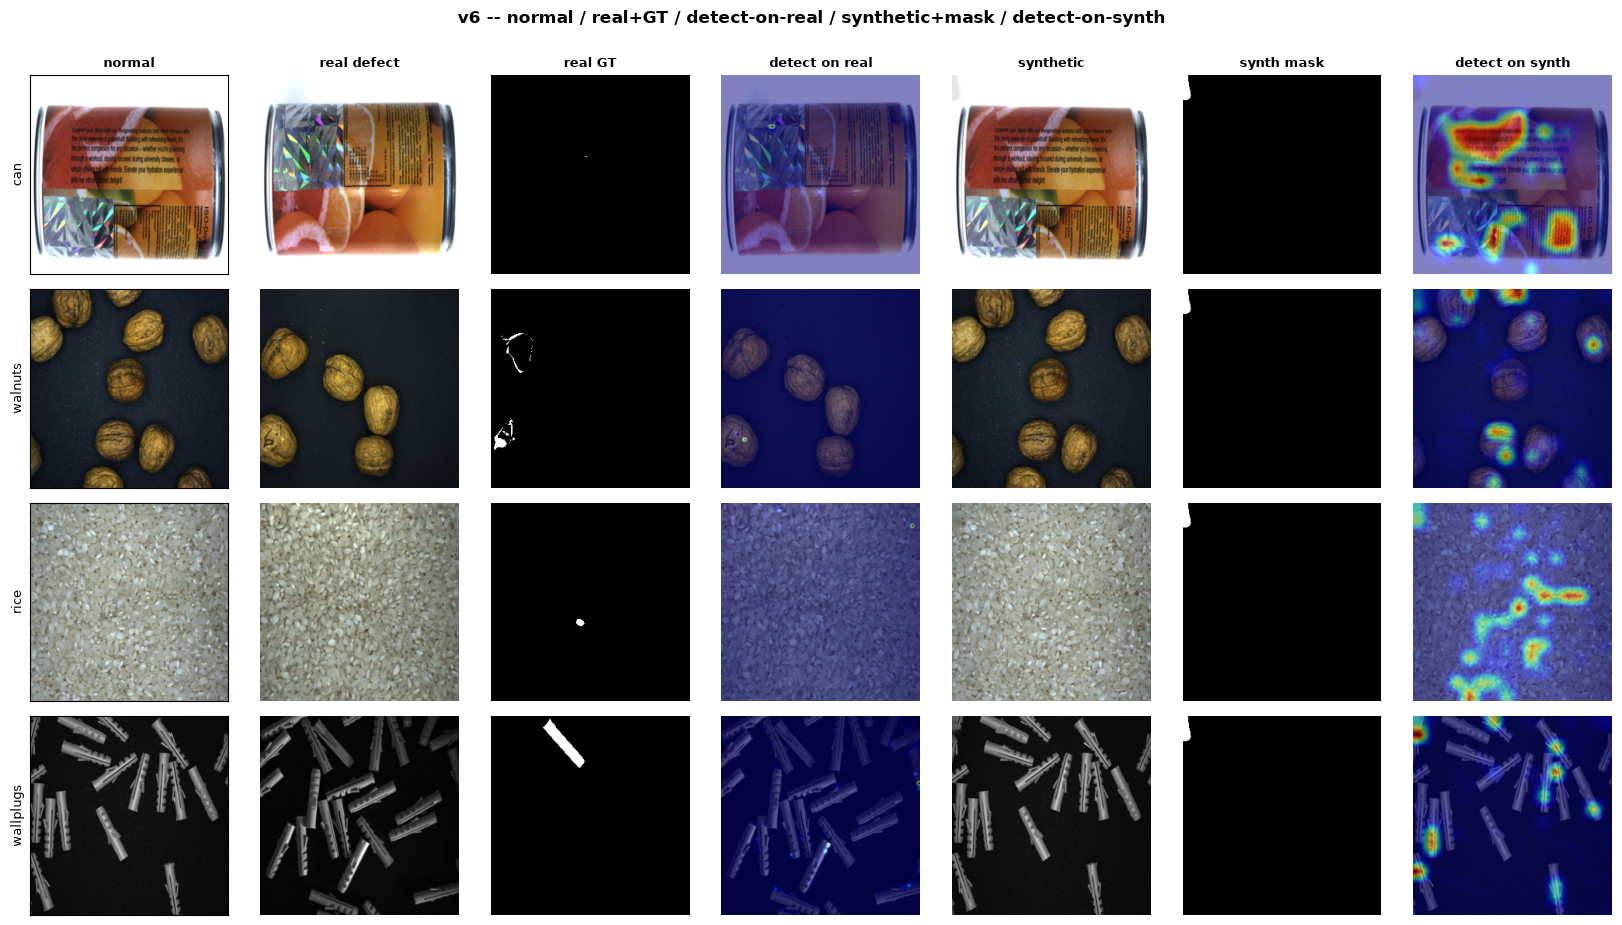

In [12]:
def gallery7(seed=0):
    n = len(CATS)
    fig, ax = plt.subplots(n, 7, figsize=(16.5, 2.3 * n)); ax = np.atleast_2d(ax)
    cols = ["normal", "real defect", "real GT", "detect on real",
            "synthetic", "synth mask", "detect on synth"]
    for r, cat in enumerate(CATS):
        for c in range(7):
            ax[r, c].axis("off")
        s, tr, te = split_real(cat, seed)
        if not te:
            continue
        bank = build_bank(cat); b = substrate(bank)
        nf = bank[torch.randperm(len(bank))[:min(len(bank), 4000)]]
        sf, _ = synth_feats(bank, b, len(nf), seed); net_s = train_disc(nf, sf, seed)
        normal_p = s["normals"][0]; real_p = s["bad"][te[0]]
        normal_img = _load(normal_p, EVAL_RES).permute(1, 2, 0).numpy()
        real_img = _load(real_p, EVAL_RES).permute(1, 2, 0).numpy(); gt = _maskload(s["mask"][te[0]])
        syn_img_t, syn_mask = synth_image(normal_p, seed)
        syn_img = syn_img_t.permute(1, 2, 0).numpy()
        hm_real = disc_map(net_s, real_p); hm_syn = disc_map_img(net_s, syn_img_t)
        panels = [(normal_img, None), (real_img, None), (gt, "gray"), (real_img, "hm_real"),
                  (syn_img, None), (syn_mask, "gray"), (syn_img, "hm_syn")]
        for c, (im, mode) in enumerate(panels):
            if mode == "gray":
                ax[r, c].imshow(im, cmap="gray")
            elif mode == "hm_real":
                ax[r, c].imshow(im); ax[r, c].imshow(hm_real, cmap="jet", alpha=0.5)
            elif mode == "hm_syn":
                ax[r, c].imshow(im); ax[r, c].imshow(hm_syn, cmap="jet", alpha=0.5)
            else:
                ax[r, c].imshow(im)
            if r == 0:
                ax[r, c].set_title(cols[c], fontsize=9, fontweight="bold")
        ax[r, 0].axis("on"); ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([]); ax[r, 0].set_ylabel(cat, fontsize=9)
        del bank, nf; gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    fig.suptitle("v6 -- normal / real+GT / detect-on-real / synthetic+mask / detect-on-synth", y=1.0, fontweight="bold")
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "v6_gallery7.png"), dpi=120, bbox_inches="tight"); plt.show()


gallery7()

In [13]:
# 6.2 Feature-consistency (H4): synthetic deviation vs real-defect deviation band
def feature_consistency():
    rows = []
    for cat in CATS:
        s, tr, te = split_real(cat, SEEDS[0])
        if not tr:
            continue
        bank = build_bank(cat); b = substrate(bank)
        sf, base = synth_feats(bank, b, 1000, 0)
        sdev = (sf - base).norm(dim=1).numpy()
        pos, _ = real_feats(cat, tr, max_pos=1000)
        rdev = (pos - bank.mean(0, keepdim=True)).norm(dim=1).numpy() if len(pos) else np.array([np.nan])
        rows.append(dict(cat=cat, synth_dev_p50=round(float(np.median(sdev)), 3),
                         real_dev_p50=round(float(np.nanmedian(rdev)), 3),
                         in_band=round(float(np.mean((sdev > np.nanpercentile(rdev, 10)) &
                                                     (sdev < np.nanpercentile(rdev, 90)))), 2)))
        del bank; gc.collect()
    print("=== H4 feature-consistency ==="); print(pd.DataFrame(rows).to_string(index=False))


feature_consistency()

=== H4 feature-consistency ===
      cat  synth_dev_p50  real_dev_p50  in_band
      can          0.778         0.902      0.0
  walnuts          0.773         0.864      1.0
     rice          0.775         0.852      1.0
wallplugs          0.779         0.951      1.0


## 6.3 Defect-grammar extension -- additive contamination

The literature frames the goal as covering *diverse* defect types while staying realistic
(near-in-distribution). v6's substrate operator covers the **subtractive** sub-family; here we add
the complementary **additive / contamination** operator so the grammar spans both structural
sub-families. It is the one extra operator that fits v6's *per-patch* discriminator: real
contamination (foreign bodies in rice, fruit_jelly, sheet_metal) genuinely sits off the object
manifold, toward foreign-material features -- so we push a normal foreground feature toward a
**foreign prototype** sampled from *other* categories' normals, with the same GLASS truncation.

Thin-morphology (crack) and logical (missing-instance, count) operators are deliberately NOT added:
a per-patch discriminator cannot exploit spatial morphology or global arrangement, so they need a
spatial detector head first (see 7). This cell measures whether contamination *actually helps* --
subtractive vs contamination vs both, against the floor.

In [14]:
def build_foreign_bank(cat, per_cat=3, cap=4000):
    # foreign material features = normals from OTHER categories (out-of-manifold but plausible)
    others = [c for c in CATS if c != cat] or [cat]
    feats = []
    for oc in others:
        for p in get_split(oc)["normals"][:per_cat]:
            feats.append(extract(p)[0])
    allf = torch.cat(feats, 0)
    return allf[torch.randperm(len(allf))[:cap]] if len(allf) > cap else allf


def synth_contamination(bank, b, foreign, n, seed, alpha=0.7, r1=0.3, r2=1.0, noise=0.15):
    g = torch.Generator().manual_seed(int(seed) + 101)
    fg = bank[(bank - b).norm(dim=1) > (bank - b).norm(dim=1).median()]     # foreground = has material to sit on
    if len(fg) == 0:
        fg = bank
    u = fg[torch.randint(0, len(fg), (n,), generator=g)]
    f = foreign[torch.randint(0, len(foreign), (n,), generator=g)]          # a foreign-material target
    a = u + alpha * (f - u) * torch.rand(n, 1, generator=g) + noise * torch.randn(n, u.shape[1], generator=g)
    delta = a - u; nrm = delta.norm(dim=1, keepdim=True).clamp(min=1e-6)
    return F.normalize(u + delta * (nrm.clamp(min=r1, max=r2) / nrm), dim=1)


def run_grammar():
    rows = []
    for cat in CATS:
        for seed in SEEDS:
            s, tr, te = split_real(cat, seed)
            if not te:
                continue
            bank = build_bank(cat); b = substrate(bank); foreign = build_foreign_bank(cat)
            val_imgs = s["val"][:10] or s["normals"][:10]
            test_imgs = [s["bad"][i] for i in te] + s["good"][:len(te)]
            gts = [_maskload(s["mask"][i]) for i in te] + [np.zeros((EVAL_RES, EVAL_RES), np.float32)
                                                           for _ in range(min(len(te), len(s["good"])))]
            nf = bank[torch.randperm(len(bank))[:min(len(bank), 4000)]]
            sub, _ = synth_feats(bank, b, len(nf), seed)
            con = synth_contamination(bank, b, foreign, len(nf), seed)
            both = torch.cat([sub[:len(nf) // 2], con[:len(nf) // 2]], 0)     # grammar = subtractive U contamination
            floor = evaluate([knn_map(p, bank) for p in val_imgs], [knn_map(p, bank) for p in test_imgs], gts)["aupro05"]
            out = {"cat": cat, "seed": seed, "tag": FAMILY[cat], "floor": round(floor, 3)}
            for name, af in [("sub", sub), ("contam", con), ("both", both)]:
                net = train_disc(nf, af, seed)
                out[name] = round(evaluate([disc_map(net, p) for p in val_imgs],
                                           [disc_map(net, p) for p in test_imgs], gts)["aupro05"], 3)
            rows.append(out)
            print(f"  {cat} s{seed}: floor={out['floor']} sub={out['sub']} contam={out['contam']} both={out['both']}")
            del bank, nf, foreign; gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return pd.DataFrame(rows)


GRAMMAR = run_grammar()
if len(GRAMMAR):
    gg = GRAMMAR.groupby(["cat", "tag"])[["floor", "sub", "contam", "both"]].mean().round(3)
    print("\n=== Defect-grammar: AU-PRO@0.05 by anomaly source ===")
    print(gg.to_string())
    print("\n=== Family-split ===")
    print(GRAMMAR.groupby("tag")[["floor", "sub", "contam", "both"]].mean().round(3).to_string())
    d_both = float((GRAMMAR.groupby("cat")["both"].mean() - GRAMMAR.groupby("cat")["sub"].mean()).mean())
    print(f"\nDoes adding contamination help? mean(both - sub) = {d_both:+.3f} "
          f"({'YES, keep it' if d_both > 0.005 else 'no clear gain -> keep subtractive-only'}).")

  can s0: floor=0.138 sub=0.011 contam=0.006 both=0.003
  walnuts s0: floor=0.113 sub=0.056 contam=0.061 both=0.055
  rice s0: floor=0.295 sub=0.244 contam=0.248 both=0.247
  wallplugs s0: floor=0.098 sub=0.021 contam=0.039 both=0.014

=== Defect-grammar: AU-PRO@0.05 by anomaly source ===
                         floor    sub  contam   both
cat       tag                                       
can       subtractive    0.138  0.011   0.006  0.003
rice      contamination  0.295  0.244   0.248  0.247
wallplugs subtractive    0.098  0.021   0.039  0.014
walnuts   mixed          0.113  0.056   0.061  0.055

=== Family-split ===
               floor    sub  contam   both
tag                                       
contamination  0.295  0.244   0.248  0.247
mixed          0.113  0.056   0.061  0.055
subtractive    0.118  0.016   0.022  0.008

Does adding contamination help? mean(both - sub) = -0.003 (no clear gain -> keep subtractive-only).


#### How to read
`contam` > `sub` on contamination/mixed categories, and `both` >= `sub` overall, means the grammar
extension pays off (keep contamination). If `both` < `sub`, the extra positives are bleeding into
normal regions -> drop it or tighten the truncation `r2`. This is the disciplined "add one operator,
measure, keep only what moves the metric" rule.

## 7. Discussion

Read `synth_gap_to_real` (H1/H3) and `synth_vs_floor` (H2). Success = `SYNTH` near the real oracle
and above the normal-only floor, especially on the subtractive family that collapsed in v5. If synth
beats the floor but trails the oracle, next levers: GLASS gradient-ascent toward the discriminator
boundary, per-category `alpha`/`r2`, and an anomaly memory bank fused with the kNN score (SuperADD
dual-bank). If synth still fails on subtractive, learn the substrate prototype per category.

**Threats.** `REAL_ORACLE` trains/tests on the same defect distribution (upper bound); few real
defects -> wide CIs (multi-seed). DINOv3 > DINOv2; the stub is plumbing only, meaningless numbers.

References: GLASS 2407.09359 - SimpleNet 2303.15140 - SuperADD 2605.14808 - MVTec AD 2 2503.21622.

In [15]:
import os
from PIL import Image as _Image
import numpy as _np

pair_dir = "./mask_diff_pair"
os.makedirs(pair_dir, exist_ok=True)

cat = "can"
normal_p = get_split(cat)["normals"][0]
best = None
for seed in range(8):
    b, m = synth_image(normal_p, seed=seed, coverage=0.035)
    frac = float(m.mean())
    if best is None or frac > best[0]:
        best = (frac, seed, b, m)
frac, seed, syn_img_t, syn_mask = best
normal_img_t = _load(normal_p, EVAL_RES)

a_u8 = (normal_img_t.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(_np.uint8)
b_u8 = (syn_img_t.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(_np.uint8)
gt_u8 = (syn_mask * 255).astype(_np.uint8)

_Image.fromarray(a_u8).save(os.path.join(pair_dir, "A_normal.png"))
_Image.fromarray(b_u8).save(os.path.join(pair_dir, "B_synthetic.png"))
_Image.fromarray(gt_u8).save(os.path.join(pair_dir, "gt_mask.png"))
print(f"cat={cat} seed={seed} mask_fraction={frac:.4f}")
print("saved to", os.path.abspath(pair_dir))


cat=can seed=5 mask_fraction=0.0295
saved to /home/devuser/workspace/code/Anomalib/anomalib/gsoc_workspace/mask_diff_pair
